# Initial Neural Network tests

This script tests 5 various Neural Network Architectures on the clenaed full reduced dataset. As it stands, all models have a specificity of 1 | Indicating poor predictive performance. 

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import tensorflow as tf
from torch.utils.data import TensorDataset, DataLoader
import os
from joblib import load
from sklearn.model_selection import train_test_split
import pandas as pd
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.style.use('bmh')

KeyboardInterrupt: 

# Data alterations as seen in the analysis notebook

In [ ]:
directory = '/mnt/hpc/work/mbouthil/Research_Project/MIMIC-III_data'
os.chdir(directory)

df = load("Master_Dataframe_reduced.joblib")

for col, col_values in df.items():
    if df[col].dtype == ('O'):
       df[col] = df[col].astype('category').cat.codes
       
    if df[col].dtype == ('<m8[ns]'):
        df[col] = df[col].dt.total_seconds()
        df[col] = df[col]/(60**2*24)

df['ed_duration'] = df['ed_duration'].clip(lower=0)
df = df[df['age'] <= 100]
df = df[df['age'] >= 1]
df = df[df['los'] <= 30]
df = df[df['admit_duration'] <= 30]
df = df[df['ed_duration'] <= 1]
df['ed_duration'] = df['ed_duration'].clip(lower=0)

In [ ]:
display(df.head())

,admission_type,admission_location,discharge_location,insurance,marital_status,ethnicity,read_flag,admit_duration,ed_duration,gender,los,age
0,1,1,3,1,1,30,0.0,1.881944,0.452778,1,0.7911,56
1,1,2,14,2,0,36,0.0,13.295139,0.088194,0,4.6201,72
2,1,2,3,1,1,13,0.0,3.095833,0.284028,0,1.1269,33
3,1,2,12,3,0,36,0.0,8.354861,0.356944,0,2.2924,30
4,1,2,4,3,0,36,0.0,8.579167,0.439583,0,1.9028,48


# Data Processing

In [ ]:
X = df.drop('read_flag', axis=1)
y = df['read_flag']

In [ ]:
def tensor_datasets(X, y): 

    '''
    Returns a training, validation and test tensor dataset
    '''

    # Stratified Split of the train and test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y,random_state=42)

    # Creation of a validaiton set
    X_train, X_val, y_train, y_val  = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    # Creation of tensor datasets
    X_train = torch.tensor(X_train.values, dtype=torch.float32)
    y_train = torch.tensor(y_train.values, dtype=torch.long)

    X_test = torch.tensor(X_test.values, dtype=torch.float32)
    y_test = torch.tensor(y_test.values, dtype=torch.long)

    X_val = torch.tensor(X_val.values, dtype=torch.float32)
    y_val = torch.tensor(y_val.values, dtype=torch.long)

    return(TensorDataset(X_train, y_train), TensorDataset(X_val, y_val), TensorDataset(X_test, y_test))

In [ ]:
def dataloaders(train_dataset, val_dataset, test_dataset, batch_size=32):

    '''
    Returns dataloaders for the given datasets. 

    Note: 
        The validation and test loaders do not have shuffling
    '''

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
batch_size = 16

train_set, val_set, test_set = tensor_datasets(X, y)
train_loader, val_loader, test_loader = dataloaders(train_set, val_set, test_set, batch_size)

# Early Stopping

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()

        elif score > self.best_score:
            self.counter += 1
            
            if self.counter >= self.patience:
                self.early_stop = True
                
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0

    def reset(self):
        self.__init__()

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)

# Base Architecture

In [ ]:
class neural_network_1(nn.Module):

    ''' 
    This Neural Network has the following structure: 

    Deep Neural Network with 3 hidden layers with 12, 
    10 and 8 neurons accordingly. The output layer has 
    1 neuron. After each layer, a relu function is applied,
    with the exeption of the output layer. 
    '''

    def __init__(self):
        super(neural_network_1, self).__init__()
        self.fc1 = nn.Linear(11, 12)
        self.fc2 = nn.Linear(12, 10)
        self.fc3 = nn.Linear(10, 8)
        self.fc4 = nn.Linear(8, 1)
        self.ReLU = nn.ReLU()

    def forward(self, X):
        X = self.ReLU(self.fc1(X))
        X = self.ReLU(self.fc2(X))
        X = self.ReLU(self.fc3(X))
        X = self.fc4(X)

        return X

# Training Loop

In [ ]:
# Sigmoid + Binary Cross Entropy Criterion -- internally applies the sigmoid function
criterion = nn.BCEWithLogitsLoss()

# Setting default paramaters
model = neural_network_1()
num_epochs = 1
learning_rate = .001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
early_stopping = EarlyStopping(patience=5)

In [ ]:
# Training Function
def train_epoch(model, progress_bar):

    loss = 0
    accuracy = 0
    samples = 0

    for X, Y in progress_bar:
        X, Y = X.to(device), Y.to(device)

        # Forward pass
        optimizer.zero_grad() 
        logits = model(X).squeeze(1)
        Y_float = Y.float()
        batch_loss = criterion(logits, Y_float)

        # Backwords pass
        batch_loss.backward()
        optimizer.step()


        # loss + accuracy calculations
        with torch.no_grad():
            size = Y.size(0)
            loss += batch_loss.item()*size
            prob = torch.sigmoid(logits)
            pred = (prob > 0.5).float()
            accuracy += (pred == Y_float).sum()
            samples += size
            progress_bar.set_postfix()
    
    avg_loss= loss/samples
    percent = accuracy/samples*100
    print(f'    Average Training Loss: {avg_loss:.4f}')
    print(f'    Training Accuracy: {percent:.2f}%')
    
    return avg_loss, percent

In [ ]:
# Validation Function
def validation(model):

    loss = 0
    accuracy = 0
    samples = 0

    with torch.no_grad():
        for X,Y in val_loader:
    
            logits = model(X).squeeze(1)
            Y_float = Y.float()
            batch_loss = criterion(logits, Y_float)

            size = Y.size(0)
            loss += batch_loss.item()*size
            prob = torch.sigmoid(logits)
            pred = (prob > .5).float()
            accuracy += (pred == Y_float).sum()
            samples += size
    
    avg_loss = loss/samples
    percent = accuracy/samples*100
    print(f'    Average Validation Loss: {avg_loss:.4f}')
    print(f'    Validation Accuracy: {percent:.2f}%')

    return avg_loss, percent

In [ ]:
def train_model(model, num_epochs):

    # Initializing Vectors to store variables
    t_loss = np.zeros(num_epochs)
    v_loss = np.zeros(num_epochs)
    t_accuracy = np.zeros(num_epochs)
    v_accuracy = np.zeros(num_epochs)
    
    # For loop for Epochs
    for epoch in range(num_epochs):

        # Training one Epoch
        model.train(True)
        progress_bar = tqdm(train_loader, desc=f"EPOCH {epoch+1}")
        t_loss[epoch], t_accuracy[epoch] = train_epoch(model, progress_bar)

        # Validation
        model.eval()
        v_loss[epoch], v_accuracy[epoch] = validation(model)

        # Early Stopping 
        early_stopping(v_loss[epoch], model)
        print('')
        if early_stopping.early_stop:
            print("Early Stop Enacted")
            t_loss=t_loss[:1+epoch]
            v_loss=v_loss[:1+epoch]
            t_accuracy=t_accuracy[:1+epoch]
            v_accuracy=v_accuracy[:1+epoch]
            break

    # Loading Best Model and Final Line
    early_stopping.load_best_model(model)
    return t_loss, v_loss, t_accuracy, v_accuracy

# Testing function

In [ ]:
# Test Function:
def evaluation(model):

    '''
    This fucntion will return performance metrics of the 
    given model on the test dataset. Function will print
    accuracy, sensitivity, specificity as well as a confusion
    matrix
    '''
    
    model.eval()
    accuracy = 0
    samples = 0

    Y_pred = []
    Y_true = []

    with torch.no_grad():
        for X,Y in test_loader:
        
            logits = model(X).squeeze(1)
            samples += Y.size(0)
            Y = Y.int().cpu().numpy()
            prob = torch.sigmoid(logits)
            pred = (prob > .5).int().cpu().numpy()
            accuracy += (pred == Y).sum()

            Y_pred.extend(pred.tolist())
            Y_true.extend(Y.tolist())

    # Confusion Matrix
    cm = confusion_matrix(Y_true, Y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    print(f'The model accruacy is of {accuracy/samples*100:.4f}%' )
    print(f'The model sensitivity is of {float(sensitivity)}')
    print(f'The model specificity is of {float(specificity)}')

    # Plotting CM
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap='YlOrRd')
    ax.set(
        xticks=[0,1], 
        yticks=[0,1],
        xticklabels=["Neg", "Pos"],
        yticklabels=["Neg", "Pos"],
        xlabel = "Predict Label",
        ylabel = "True Label",
        title = 'Confusion Matrix'
    )

    for i in range(2):
        for j in range(2):
            ax.text(j,i, cm[i,j], ha="center", va="center")

    # plt.style.use('bmh')
    plt.show()        

# Neural Network 1

### Model + Training

In [ ]:
# Loading Data 
batch_size = 64
train_set, val_set, test_set = tensor_datasets(X, y)
train_loader, val_loader, test_loader = dataloaders(train_set, val_set, test_set, batch_size)

# Model specifications
model = neural_network_1()
criterion = nn.BCEWithLogitsLoss()
num_epochs = 30
learning_rate = .001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
early_stopping = EarlyStopping(patience=5)

# Training the model
t_loss, v_loss, t_accuracy, v_accuracy = train_model(model, num_epochs)

EPOCH 1:   0%|          | 0/305 [00:00<?, ?it/s]

EPOCH 1: 100%|██████████| 305/305 [00:01<00:00, 254.93it/s]


    Average Training Loss: 0.2491
    Training Accuracy: 94.18%
    Average Validation Loss: 0.2291
    Validation Accuracy: 94.17%



EPOCH 2: 100%|██████████| 305/305 [00:01<00:00, 277.58it/s]


    Average Training Loss: 0.2201
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2240
    Validation Accuracy: 94.17%



...

    Average Training Loss: 0.2125
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2173
    Validation Accuracy: 94.17%



EPOCH 23: 100%|██████████| 305/305 [00:01<00:00, 273.53it/s]


    Average Training Loss: 0.2122
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2188
    Validation Accuracy: 94.17%



EPOCH 24: 100%|██████████| 305/305 [00:01<00:00, 263.26it/s]


    Average Training Loss: 0.2123
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2172
    Validation Accuracy: 94.17%

Early Stop Enacted


### Results

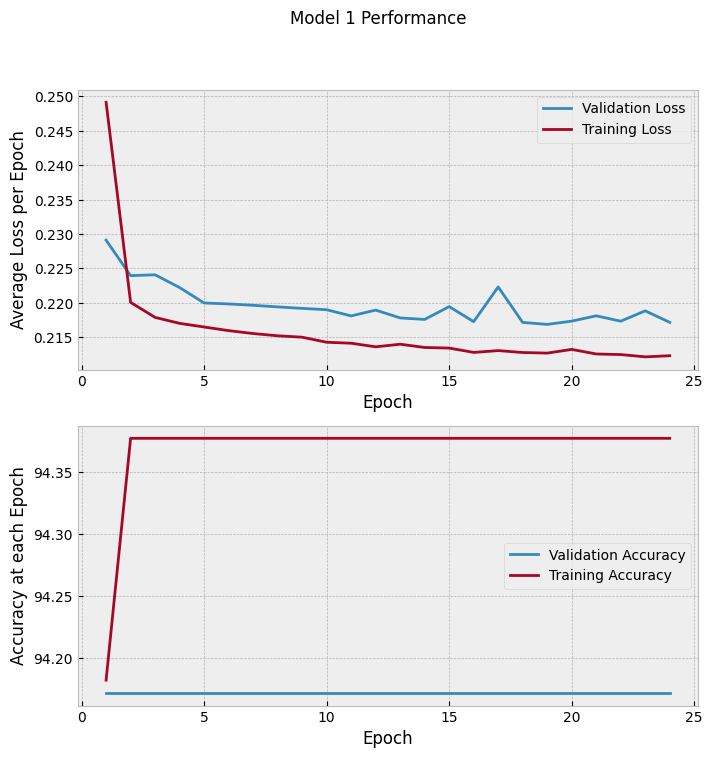

In [ ]:
# Plotting the Figure
fig, ax = plt.subplots(2, figsize=(8, 8))
fig.suptitle("Model 1 Performance")

ax[0].plot(range(1,len(v_loss)+1), v_loss, label="Validation Loss", linestyle="-")
ax[0].plot(range(1,len(t_loss)+1), t_loss, label="Training Loss", linestyle="-")

ax[0].set_ylabel("Average Loss per Epoch")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(range(1,len(v_accuracy)+1), v_accuracy, label="Validation Accuracy", linestyle="-")
ax[1].plot(range(1,len(t_accuracy)+1), t_accuracy, label="Training Accuracy", linestyle="-")

ax[1].set_ylabel("Accuracy at each Epoch")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.style.use('bmh')
plt.show()

The model accruacy is of 94.3368%
The model sensitivity is of 0.0
The model specificity is of 1.0


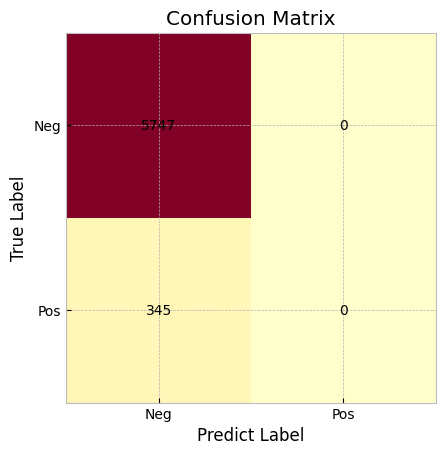

In [ ]:
# Model Accuracy in Testing data:
# accuracy, sensitivity, specificity = test_results(model)
# print(float(accuracy))
# print(float(sensitivity))
# print(float(specificity))

evaluation(model)

# Neural Network 2

### Architecture + Training

In [ ]:
class neural_network_2(nn.Module):

    '''
    This Neural Network has the following structure:

    Deep Neural Network with 6 hidden layers, with the first
    containing 14 neurons, and each following hidden layer
    have 2 neurons less than the proceding. Each layer utilizes
    Leaky Relu activation functions with the exeption of the output
    layer. 
    '''

    def __init__(self):
        super(neural_network_2, self).__init__()
        self.fc1 = nn.Linear(11, 14)
        self.fc2 = nn.Linear(14, 12)
        self.fc3 = nn.Linear(12, 10)
        self.fc4 = nn.Linear(10, 8)
        self.fc5 = nn.Linear(8, 6)
        self.fc6 = nn.Linear(6, 4)
        self.fc7 = nn.Linear(4, 2)
        self.fc8 = nn.Linear(2, 1)
        self.lrelu = nn.LeakyReLU()

    def forward(self, X):
        X = self.lrelu(self.fc1(X))
        X = self.lrelu(self.fc2(X))
        X = self.lrelu(self.fc3(X))
        X = self.lrelu(self.fc4(X))
        X = self.lrelu(self.fc5(X))
        X = self.lrelu(self.fc6(X))
        X = self.lrelu(self.fc7(X))
        X = self.fc8(X)
        
        return(X)

In [ ]:
# Loading Data 
batch_size = 64
train_set, val_set, test_set = tensor_datasets(X, y)
train_loader, val_loader, test_loader = dataloaders(train_set, val_set, test_set, batch_size)

# Model specifications
model_2 = neural_network_2()
criterion = nn.BCEWithLogitsLoss()
num_epochs = 30
learning_rate = .001
optimizer = optim.Adam(model_2.parameters(), lr=learning_rate)
early_stopping = EarlyStopping(patience=5)

# Training the model
t_loss2, v_loss2, t_accuracy2, v_accuracy2 = train_model(model_2, num_epochs)

EPOCH 1: 100%|██████████| 305/305 [00:01<00:00, 202.17it/s]


    Average Training Loss: 0.3228
    Training Accuracy: 84.80%
    Average Validation Loss: 0.2353
    Validation Accuracy: 94.17%



EPOCH 2: 100%|██████████| 305/305 [00:01<00:00, 216.08it/s]


    Average Training Loss: 0.2243
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2295
    Validation Accuracy: 94.17%



EPOCH 3: 100%|██████████| 305/305 [00:01<00:00, 206.74it/s]


...

    Average Training Loss: 0.2127
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2182
    Validation Accuracy: 94.17%



EPOCH 25: 100%|██████████| 305/305 [00:01<00:00, 188.20it/s]


    Average Training Loss: 0.2126
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2182
    Validation Accuracy: 94.17%



EPOCH 26: 100%|██████████| 305/305 [00:01<00:00, 202.70it/s]


    Average Training Loss: 0.2123
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2177
    Validation Accuracy: 94.17%

Early Stop Enacted


### Results

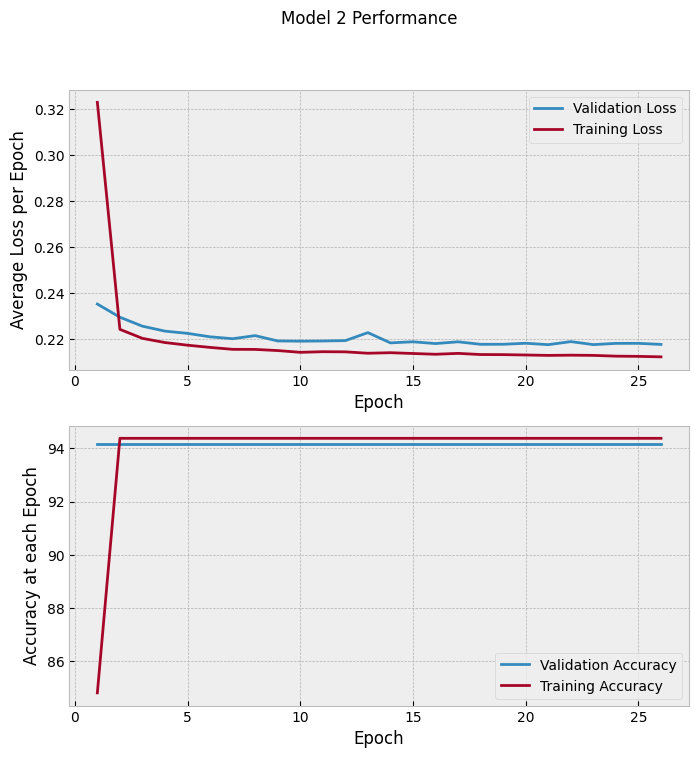

In [ ]:
# Plotting the Figure
fig, ax = plt.subplots(2, figsize=(8, 8))
fig.suptitle("Model 2 Performance")

ax[0].plot(range(1,len(v_loss2)+1), v_loss2, label="Validation Loss", linestyle="-")
ax[0].plot(range(1,len(t_loss2)+1), t_loss2, label="Training Loss", linestyle="-")

ax[0].set_ylabel("Average Loss per Epoch")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(range(1,len(v_accuracy2)+1), v_accuracy2, label="Validation Accuracy", linestyle="-")
ax[1].plot(range(1,len(t_accuracy2)+1), t_accuracy2, label="Training Accuracy", linestyle="-")

ax[1].set_ylabel("Accuracy at each Epoch")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.style.use('bmh')
plt.show()

The model accruacy is of 94.3368%
The model sensitivity is of 0.0
The model specificity is of 1.0


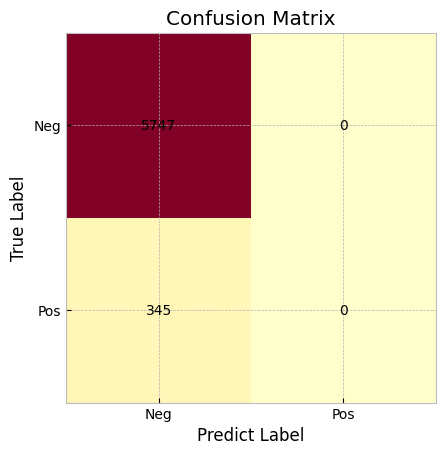

In [ ]:
evaluation(model_2)

# Neural Network 3

### Model + Training

In [ ]:
class neural_network_3(nn.Module):
    
    '''
    This Neural Network has the following structure:

    Deep Neural Network with 6 hidden layers, with the first
    containing 14 neurons, and each following hidden layer
    have 2 neurons less than the proceding. Each layer utilizes
    Relu activation functions with the exeption of the output
    layer. 
    '''

    def __init__(self):
        super(neural_network_3, self).__init__()
        self.fc1 = nn.Linear(11, 14)
        self.fc2 = nn.Linear(14, 12)
        self.fc3 = nn.Linear(12, 10)
        self.fc4 = nn.Linear(10, 8)
        self.fc5 = nn.Linear(8, 6)
        self.fc6 = nn.Linear(6, 4)
        self.fc7 = nn.Linear(4, 2)
        self.fc8 = nn.Linear(2, 1)
        self.relu = nn.ReLU()

    def forward(self, X):
        X = self.relu(self.fc1(X))
        X = self.relu(self.fc2(X))
        X = self.relu(self.fc3(X))
        X = self.relu(self.fc4(X))
        X = self.relu(self.fc5(X))
        X = self.relu(self.fc6(X))
        X = self.relu(self.fc7(X))
        X = self.fc8(X)
        
        return(X)

In [ ]:
# Loading Data 
batch_size = 64
train_set, val_set, test_set = tensor_datasets(X, y)
train_loader, val_loader, test_loader = dataloaders(train_set, val_set, test_set, batch_size)

# Model specifications
model_3 = neural_network_3()
criterion = nn.BCEWithLogitsLoss()

# Note: Smaller Learning rate and max 50 epochs from the previous 30
num_epochs = 50
learning_rate = .0001


optimizer = optim.Adam(model_3.parameters(), lr=learning_rate)
early_stopping = EarlyStopping(patience=5)

# Training the model
t_loss3, v_loss3, t_accuracy3, v_accuracy3 = train_model(model_3, num_epochs)

EPOCH 1: 100%|██████████| 305/305 [00:01<00:00, 202.15it/s]


    Average Training Loss: 0.4047
    Training Accuracy: 94.38%
    Average Validation Loss: 0.3537
    Validation Accuracy: 94.17%



EPOCH 2: 100%|██████████| 305/305 [00:01<00:00, 198.48it/s]


    Average Training Loss: 0.2663
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2311
    Validation Accuracy: 94.17%



EPOCH 3: 100%|██████████| 305/305 [00:01<00:00, 199.04it/s]


...

    Average Training Loss: 0.2138
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2191
    Validation Accuracy: 94.17%



EPOCH 49: 100%|██████████| 305/305 [00:01<00:00, 180.04it/s]


    Average Training Loss: 0.2138
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2191
    Validation Accuracy: 94.17%



EPOCH 50: 100%|██████████| 305/305 [00:01<00:00, 179.98it/s]


    Average Training Loss: 0.2137
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2190
    Validation Accuracy: 94.17%



### Results

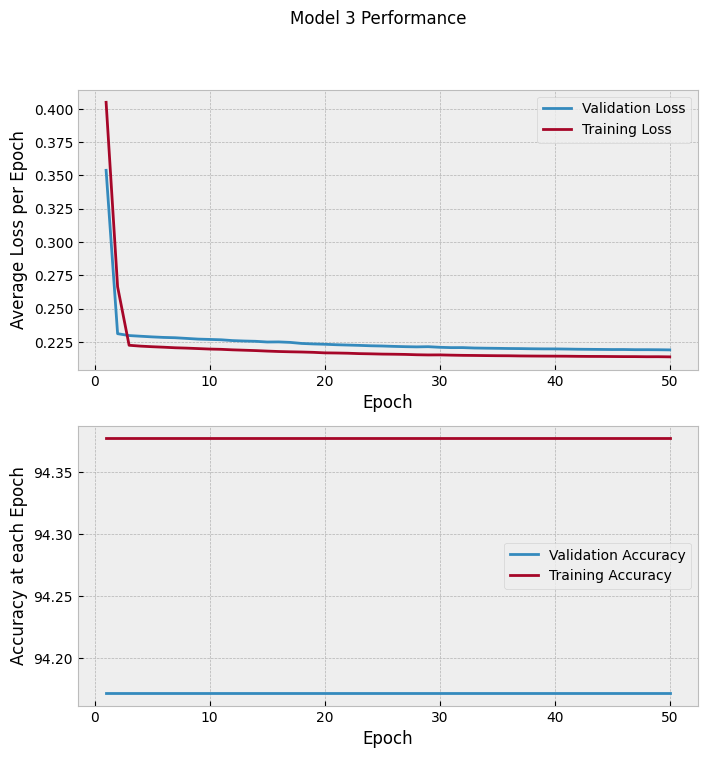

In [ ]:
# Plotting the Figure
fig, ax = plt.subplots(2, figsize=(8, 8))
fig.suptitle("Model 3 Performance")

ax[0].plot(range(1,len(v_loss3)+1), v_loss3, label="Validation Loss", linestyle="-")
ax[0].plot(range(1,len(t_loss3)+1), t_loss3, label="Training Loss", linestyle="-")

ax[0].set_ylabel("Average Loss per Epoch")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(range(1,len(v_accuracy3)+1), v_accuracy3, label="Validation Accuracy", linestyle="-")
ax[1].plot(range(1,len(t_accuracy3)+1), t_accuracy3, label="Training Accuracy", linestyle="-")

ax[1].set_ylabel("Accuracy at each Epoch")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.style.use('bmh')
plt.show()

The model accruacy is of 94.3368%
The model sensitivity is of 0.0
The model specificity is of 1.0


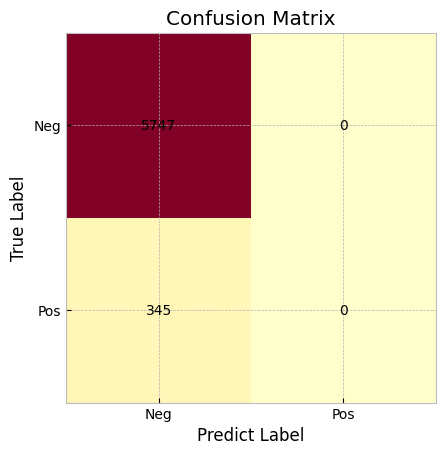

In [ ]:
evaluation(model_3)

# Neural Network 4

### Architecture + Training

This model uses the same architecture as the third

In [ ]:
# Loading Data 
batch_size = 64
train_set, val_set, test_set = tensor_datasets(X, y)
train_loader, val_loader, test_loader = dataloaders(train_set, val_set, test_set, batch_size)

# Model specifications
model_3 = neural_network_3()
criterion = nn.BCEWithLogitsLoss()
num_epochs = 50
learning_rate = .001

# This model utilized SGD optimizer 
optimizer = torch.optim.SGD(
    model_3.parameters(), 
    lr=0.1, 
    momentum=0.9, 
    weight_decay=1e-4
)

early_stopping = EarlyStopping(patience=5)

# Training the model
t_loss4, v_loss4, t_accuracy4, v_accuracy4 = train_model(model_3, num_epochs)

EPOCH 1: 100%|██████████| 305/305 [00:01<00:00, 236.87it/s]


    Average Training Loss: 0.2244
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2222
    Validation Accuracy: 94.17%



EPOCH 2: 100%|██████████| 305/305 [00:01<00:00, 249.69it/s]


    Average Training Loss: 0.2170
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2223
    Validation Accuracy: 94.17%



EPOCH 3: 100%|██████████| 305/305 [00:01<00:00, 230.71it/s]


...

    Average Training Loss: 0.2170
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2222
    Validation Accuracy: 94.17%



EPOCH 7: 100%|██████████| 305/305 [00:01<00:00, 227.96it/s]


    Average Training Loss: 0.2168
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2232
    Validation Accuracy: 94.17%



EPOCH 8: 100%|██████████| 305/305 [00:01<00:00, 221.00it/s]


    Average Training Loss: 0.2169
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2229
    Validation Accuracy: 94.17%

Early Stop Enacted


### Results

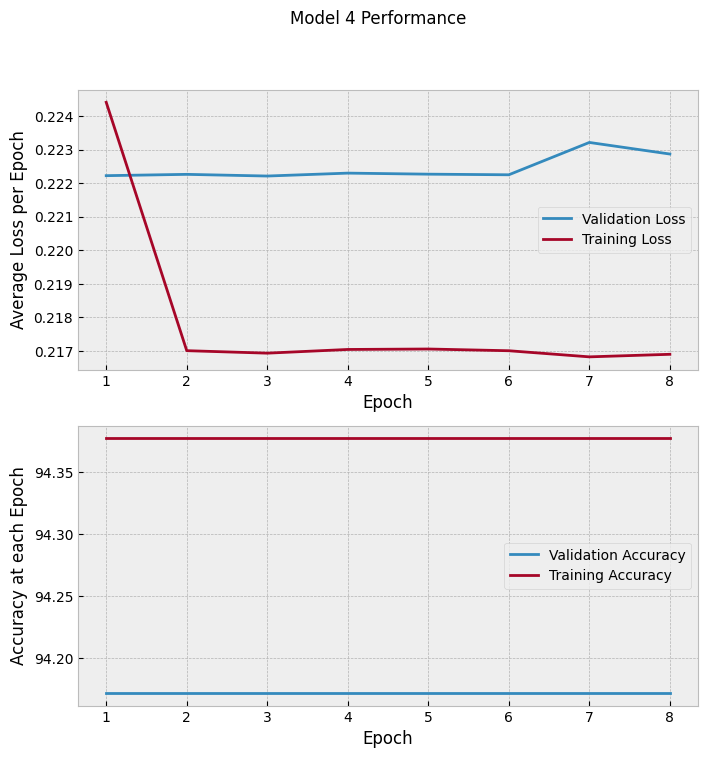

In [ ]:
# Plotting the Figure
fig, ax = plt.subplots(2, figsize=(8, 8))
fig.suptitle("Model 4 Performance")

ax[0].plot(range(1,len(v_loss4)+1), v_loss4, label="Validation Loss", linestyle="-")
ax[0].plot(range(1,len(t_loss4)+1), t_loss4, label="Training Loss", linestyle="-")

ax[0].set_ylabel("Average Loss per Epoch")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(range(1,len(v_accuracy4)+1), v_accuracy4, label="Validation Accuracy", linestyle="-")
ax[1].plot(range(1,len(t_accuracy4)+1), t_accuracy4, label="Training Accuracy", linestyle="-")

ax[1].set_ylabel("Accuracy at each Epoch")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.style.use('bmh')
plt.show()

The model accruacy is of 94.3368%
The model sensitivity is of 0.0
The model specificity is of 1.0


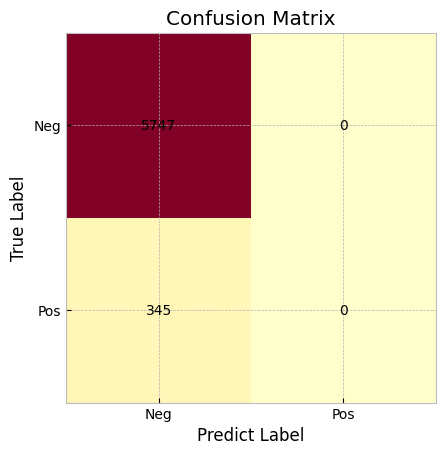

In [ ]:
evaluation(model_3)

# Neural Network 5

### Architecture + Training

In [ ]:
class neural_network_5(nn.Module):

    '''
    This Neural Network has the following structure:

    This Neural Network contains two hidden layers, the first 
    containing 25 neurons and the second 12. This is accompanied
    by the PReLU activation function. 
    '''

    def __init__(self):
        super(neural_network_5, self).__init__()
        self.fc1 = nn.Linear(11, 25)
        self.fc2 = nn.Linear(25, 12)
        self.fc3 = nn.Linear(12, 1)
        self.prelu = nn.PReLU(num_parameters=1, init=0.25) 

    def forward(self, X):
        X = self.prelu(self.fc1(X))
        X = self.prelu(self.fc2(X))
        X = self.fc3(X)
        
        return(X)

In [ ]:
# Loading Data 
batch_size = 64
train_set, val_set, test_set = tensor_datasets(X, y)
train_loader, val_loader, test_loader = dataloaders(train_set, val_set, test_set, batch_size)

# Model specifications
model_5 = neural_network_5()
criterion = nn.BCEWithLogitsLoss()
num_epochs = 50
learning_rate = .0001
optimizer = optim.Adam(model_5.parameters(), lr=learning_rate)
early_stopping = EarlyStopping(patience=5)

# Training the model
t_loss5, v_loss5, t_accuracy5, v_accuracy5 = train_model(model_5, num_epochs)

EPOCH 1: 100%|██████████| 305/305 [00:01<00:00, 255.32it/s]


    Average Training Loss: 0.2327
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2359
    Validation Accuracy: 94.17%



EPOCH 2: 100%|██████████| 305/305 [00:01<00:00, 254.79it/s]


    Average Training Loss: 0.2249
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2309
    Validation Accuracy: 94.17%



EPOCH 3: 100%|██████████| 305/305 [00:01<00:00, 254.81it/s]


...

    Average Training Loss: 0.2137
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2180
    Validation Accuracy: 94.17%



EPOCH 49: 100%|██████████| 305/305 [00:01<00:00, 275.04it/s]


    Average Training Loss: 0.2136
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2182
    Validation Accuracy: 94.17%



EPOCH 50: 100%|██████████| 305/305 [00:01<00:00, 274.80it/s]


    Average Training Loss: 0.2136
    Training Accuracy: 94.38%
    Average Validation Loss: 0.2190
    Validation Accuracy: 94.17%



### Results

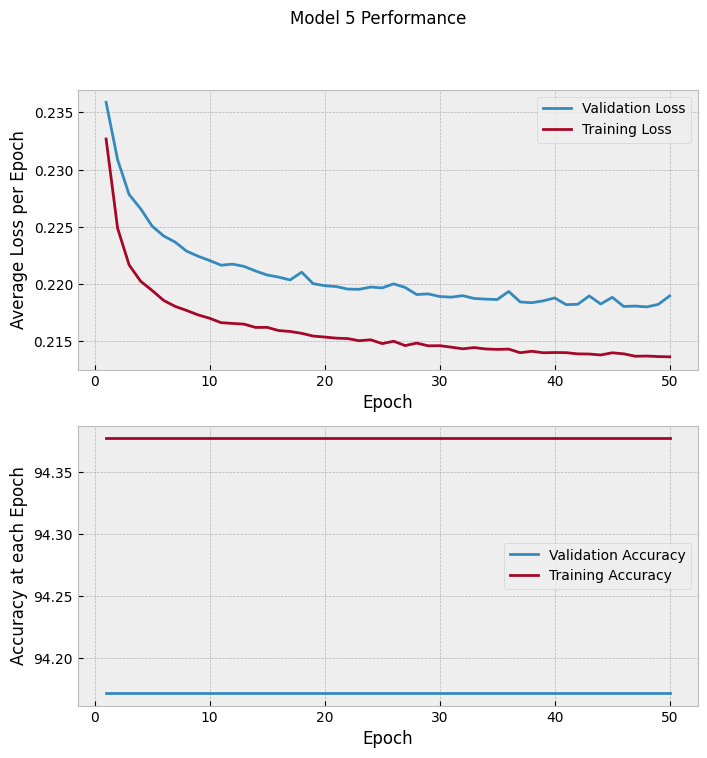

In [ ]:
# Plotting the Figure
fig, ax = plt.subplots(2, figsize=(8, 8))
fig.suptitle("Model 5 Performance")

ax[0].plot(range(1,len(v_loss5)+1), v_loss5, label="Validation Loss", linestyle="-")
ax[0].plot(range(1,len(t_loss5)+1), t_loss5, label="Training Loss", linestyle="-")

ax[0].set_ylabel("Average Loss per Epoch")
ax[0].set_xlabel("Epoch")
ax[0].legend()

ax[1].plot(range(1,len(v_accuracy5)+1), v_accuracy5, label="Validation Accuracy", linestyle="-")
ax[1].plot(range(1,len(t_accuracy5)+1), t_accuracy5, label="Training Accuracy", linestyle="-")

ax[1].set_ylabel("Accuracy at each Epoch")
ax[1].set_xlabel("Epoch")
ax[1].legend()

plt.style.use('bmh')
plt.show()

The model accruacy is of 94.3368%
The model sensitivity is of 0.0
The model specificity is of 1.0


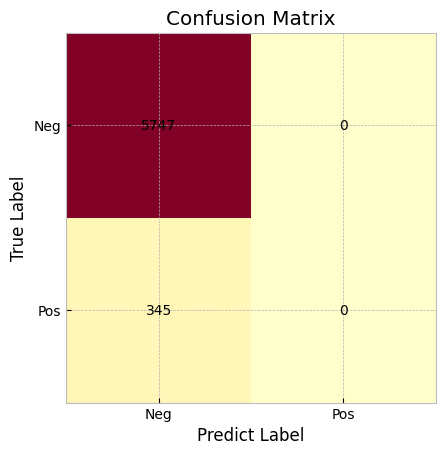

In [ ]:
evaluation(model_5)